In [1]:
# ── Imports ────────────────────────────────────────────────────
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import cv2

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
# ── Config ─────────────────────────────────────────────────────
BASE_DIR = Path('/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset')

CLASS_MAP = {
    'Normal': 0,
    'Viral Pneumonia': 1
}

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 0.0005
PATIENCE   = 5

SAVE_DIR   = '/kaggle/working/VGG16'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Outputs will be saved to: {SAVE_DIR}')

Outputs will be saved to: /kaggle/working/VGG16


In [3]:
# ── Build File List ────────────────────────────────────────────
file_paths, labels = [], []

for class_name, label in CLASS_MAP.items():
    class_dir = BASE_DIR / class_name / 'images'
    if not class_dir.exists():
        class_dir = BASE_DIR / class_name
    images = list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpg'))
    file_paths.extend(images)
    labels.extend([label] * len(images))
    print(f'{class_name}: {len(images)} images  →  label {label}')

print(f'\nTotal: {len(file_paths)} | Normal: {labels.count(0)} | Viral Pneumonia: {labels.count(1)}')

# ── Stratified 70 / 15 / 15 Split ─────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    file_paths, labels, test_size=0.30, stratify=labels, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Normal: 10192 images  →  label 0
Viral Pneumonia: 1345 images  →  label 1

Total: 11537 | Normal: 10192 | Viral Pneumonia: 1345
Train: 8075 | Val: 1731 | Test: 1731


In [4]:
# ── Dataset & DataLoaders ──────────────────────────────────────
class ChestXRayDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths; self.labels = labels; self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(ChestXRayDataset(X_train, y_train, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=False)
val_loader   = DataLoader(ChestXRayDataset(X_val,   y_val,   val_test_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=False)
test_loader  = DataLoader(ChestXRayDataset(X_test,  y_test,  val_test_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=False)

test_dataset = ChestXRayDataset(X_test, y_test, val_test_transform)
print('DataLoaders ready.')

DataLoaders ready.


In [5]:
# ── Build VGG-16 ───────────────────────────────────────────────
def build_vgg16(num_classes=2, pretrained=True):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None)

    # Replace the last layer of the classifier with Dropout + Linear
    model.classifier[-1] = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(4096, num_classes)
    )
    return model

model = build_vgg16(num_classes=2, pretrained=True).to(DEVICE)
print(model.classifier)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 219MB/s]  


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=4096, out_features=2, bias=True)
  )
)


In [6]:
# ── Training Loop with Early Stopping ─────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss, patience_count, best_weights = float('inf'), 0, None

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
        total += imgs.size(0)
    train_loss, train_acc = running_loss / total, correct / total

    # Validate
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out = model(imgs)
            running_loss += criterion(out, lbls).item() * imgs.size(0)
            correct += (out.argmax(1) == lbls).sum().item()
            total += imgs.size(0)
    val_loss, val_acc = running_loss / total, correct / total

    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc);   history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch:02d}/{EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss; patience_count = 0
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, f'{SAVE_DIR}/best_model.pth')
        print('  ✔ Best model saved')
    else:
        patience_count += 1
        print(f'  ✗ No improvement ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print('Early stopping triggered!'); break

model.load_state_dict(best_weights)

# ── Save Model ─────────────────────────────────────────────────
torch.save(model, f'{SAVE_DIR}/vgg16_full_model.pth')
torch.save(model.state_dict(), f'{SAVE_DIR}/vgg16_state_dict.pth')
print(f'Model saved to {SAVE_DIR}/')
print('\nBest weights restored.')

Epoch [01/20]  Train Loss: 0.2406  Acc: 0.9040  |  Val Loss: 0.0984  Acc: 0.9665
  ✔ Best model saved
Epoch [02/20]  Train Loss: 0.1277  Acc: 0.9560  |  Val Loss: 0.0617  Acc: 0.9775
  ✔ Best model saved
Epoch [03/20]  Train Loss: 0.0945  Acc: 0.9671  |  Val Loss: 0.0704  Acc: 0.9723
  ✗ No improvement (1/5)
Epoch [04/20]  Train Loss: 0.0823  Acc: 0.9721  |  Val Loss: 0.0849  Acc: 0.9665
  ✗ No improvement (2/5)
Epoch [05/20]  Train Loss: 0.0691  Acc: 0.9746  |  Val Loss: 0.0585  Acc: 0.9763
  ✔ Best model saved
Epoch [06/20]  Train Loss: 0.1317  Acc: 0.9559  |  Val Loss: 0.0970  Acc: 0.9671
  ✗ No improvement (1/5)
Epoch [07/20]  Train Loss: 0.1739  Acc: 0.9385  |  Val Loss: 0.0964  Acc: 0.9757
  ✗ No improvement (2/5)
Epoch [08/20]  Train Loss: 0.0914  Acc: 0.9682  |  Val Loss: 0.0957  Acc: 0.9619
  ✗ No improvement (3/5)
Epoch [09/20]  Train Loss: 0.0734  Acc: 0.9745  |  Val Loss: 0.0487  Acc: 0.9815
  ✔ Best model saved
Epoch [10/20]  Train Loss: 0.0633  Acc: 0.9786  |  Val Loss: 0

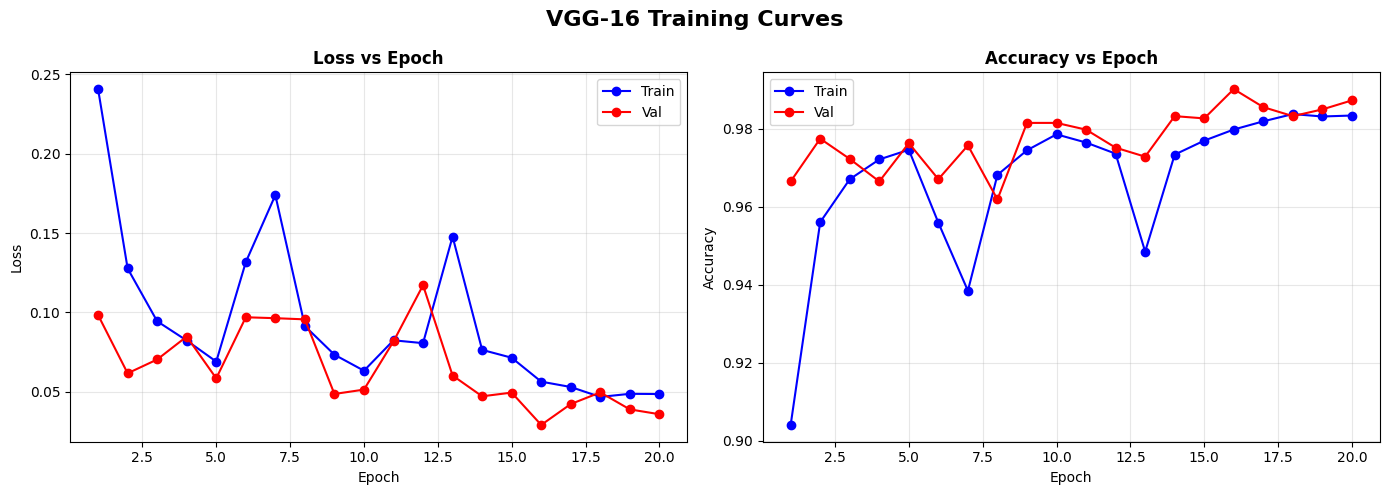

In [7]:
# ── Training / Validation Curves ──────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss vs Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy vs Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('VGG-16 Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=150); plt.show()

In [8]:
# ── Test Set Evaluation ────────────────────────────────────────
model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(DEVICE))
        all_probs.extend(torch.softmax(out, 1)[:, 1].cpu().numpy())
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(lbls.numpy())

all_preds = np.array(all_preds); all_probs = np.array(all_probs); all_labels = np.array(all_labels)

acc         = accuracy_score(all_labels, all_preds)
precision   = precision_score(all_labels, all_preds)
recall      = recall_score(all_labels, all_preds)
f1          = f1_score(all_labels, all_preds)
roc_auc     = roc_auc_score(all_labels, all_probs)
cm          = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print('=' * 45)
print('        VGG-16  ─  Test Results')
print('=' * 45)
for name, val in [('Accuracy', acc), ('Precision', precision), ('Recall', recall),
                  ('Specificity', specificity), ('F1-Score', f1), ('ROC-AUC', roc_auc)]:
    print(f'  {name:<12}: {val:.4f}')
print('=' * 45)

        VGG-16  ─  Test Results
  Accuracy    : 0.9902
  Precision   : 0.9695
  Recall      : 0.9455
  Specificity : 0.9961
  F1-Score    : 0.9574
  ROC-AUC     : 0.9990


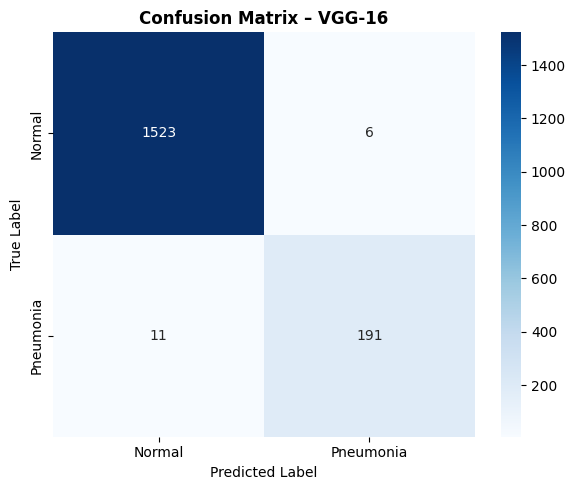

In [9]:
# ── Confusion Matrix ───────────────────────────────────────────
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix – VGG-16', fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150); plt.show()

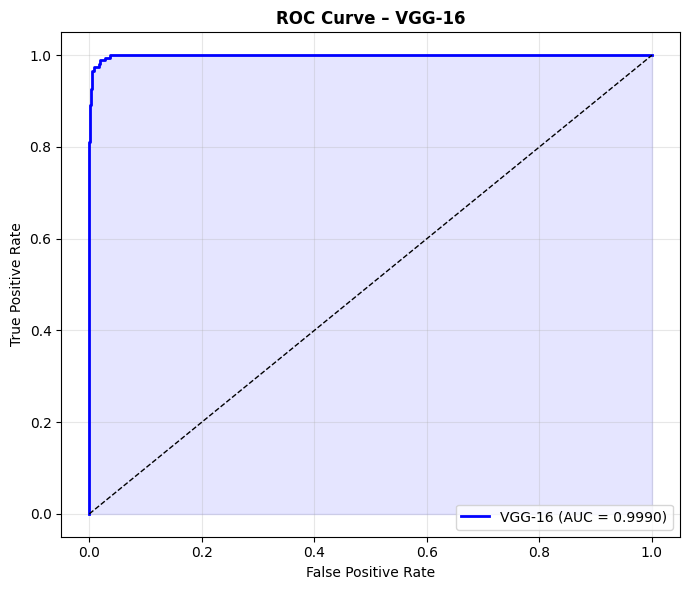

In [17]:
# ── ROC Curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'VGG-16 (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.fill_between(fpr, tpr, alpha=0.1, color='blue')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve – VGG-16', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/roc_curve.png', dpi=150); plt.show()

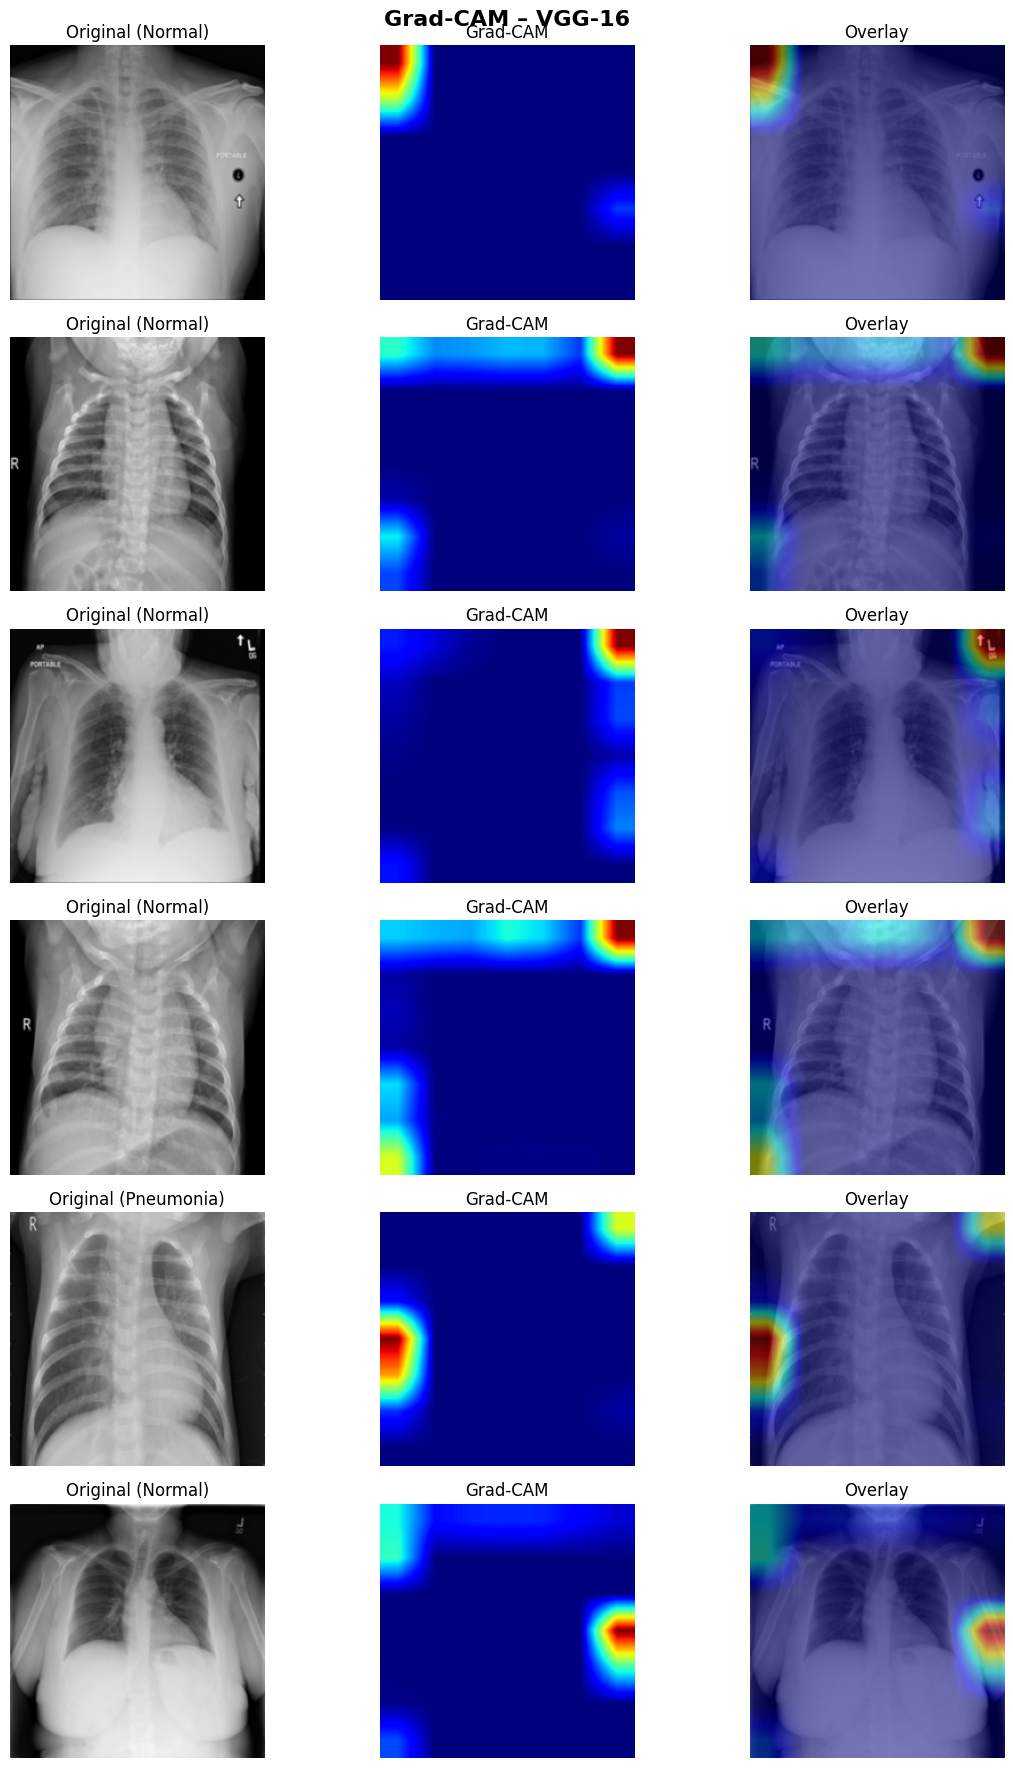

In [22]:
# ── Grad-CAM ───────────────────────────────────────────────────
# VGG16 uses 'features' instead of 'layer4' — target the last conv layer
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.gradients = None; self.activations = None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, x, class_idx=None):
        out = self.model(x)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad(); out[0, class_idx].backward()
        cam = torch.relu((self.gradients.mean([2, 3], keepdim=True) * self.activations).sum(1)).squeeze()
        cam = cam.cpu().numpy(); cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


inv_norm = transforms.Compose([
    transforms.Normalize([0,0,0], [1/0.229, 1/0.224, 1/0.225]),
    transforms.Normalize([-0.485,-0.456,-0.406], [1,1,1])
])

# VGG16 target layer → last conv layer in features block
gradcam = GradCAM(model, model.features[-1])
num_samples = 6
fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 3))
fig.suptitle('Grad-CAM – VGG-16', fontsize=16, fontweight='bold')

for row, idx in enumerate(random.sample(range(len(test_dataset)), num_samples)):
    img_t, label = test_dataset[idx]
    cam = gradcam.generate(img_t.unsqueeze(0).to(DEVICE))
    cam_up = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    orig = np.clip(inv_norm(img_t).permute(1,2,0).numpy(), 0, 1)
    heat = np.clip(cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam_up), cv2.COLORMAP_JET),
                                cv2.COLOR_BGR2RGB) / 255.0, 0, 1)
    overlay = np.clip(0.5*orig + 0.5*heat, 0, 1)
    cls = 'Normal' if label == 0 else 'Pneumonia'
    for ax, img, title in zip(axes[row], [orig, cam_up, overlay],
                               [f'Original ({cls})', 'Grad-CAM', 'Overlay']):
        ax.imshow(img, cmap='jet' if title=='Grad-CAM' else None)
        ax.set_title(title); ax.axis('off')

plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/gradcam.png', dpi=150); plt.show()

In [12]:
# ── Final Summary Table ────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model': 'VGG-16', 'Accuracy': round(acc,4), 'Precision': round(precision,4),
    'Recall': round(recall,4), 'Specificity': round(specificity,4),
    'F1-Score': round(f1,4), 'ROC-AUC': round(roc_auc,4)
}])
print(results_df.to_string(index=False))
results_df.to_csv(f'{SAVE_DIR}/results.csv', index=False)
print(f'\nResults saved to {SAVE_DIR}/results.csv')

 Model  Accuracy  Precision  Recall  Specificity  F1-Score  ROC-AUC
VGG-16    0.9902     0.9695  0.9455       0.9961    0.9574    0.999

Results saved to /kaggle/working/VGG16/results.csv


In [ ]:
# ── Reload Model ───────────────────────────────────────────────
# Option 1 — Full model (easiest)
model = torch.load(f'{SAVE_DIR}/vgg16_full_model.pth', map_location=DEVICE)
model.eval()

# Option 2 — State dict
# model = build_vgg16(num_classes=2, pretrained=False)
# model.load_state_dict(torch.load(f'{SAVE_DIR}/vgg16_state_dict.pth', map_location=DEVICE))
# model = model.to(DEVICE)
# model.eval()